In [3]:
import pandas as pd

In [4]:
df = pd.read_excel("Insurance Purchase-1.xlsx")
df.head()

,AcctAge,DDA,DDABal,CashBk,Checks,DirDep,NSF,NSFAmt,Phone,Teller,...,CRScore,Moved,InArea,Ins,Branch,Res,Dep,DepAmt,Inv,InvBal
0,0.3,1,419.27,0,0,0,0,0.0,0.0,0,...,696.0,0,1,1,B17,R,2,1170.06,0.0,0.0
1,0.7,1,1986.81,0,1,1,0,0.0,0.0,0,...,674.0,0,1,0,B2,R,1,446.93,0.0,0.0
2,4.1,0,0.00,0,0,0,0,0.0,0.0,0,...,640.0,0,1,1,B3,S,0,0.00,0.0,0.0
3,0.5,1,1594.84,0,1,0,0,0.0,0.0,1,...,672.0,0,1,0,B1,S,1,1144.24,0.0,0.0
4,6.7,1,2813.45,0,2,0,0,0.0,0.0,5,...,648.0,0,1,1,B1,S,2,1208.94,0.0,0.0


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 32264 entries, 0 to 32263
Data columns (total 48 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AcctAge  30194 non-null  float64
 1   DDA      32264 non-null  int64  
 2   DDABal   32264 non-null  float64
 3   CashBk   32264 non-null  int64  
 4   Checks   32264 non-null  int64  
 5   DirDep   32264 non-null  int64  
 6   NSF      32264 non-null  int64  
 7   NSFAmt   32264 non-null  float64
 8   Phone    28131 non-null  float64
 9   Teller   32264 non-null  int64  
 10  Sav      32264 non-null  int64  
 11  SavBal   32264 non-null  float64
 12  ATM      32264 non-null  int64  
 13  ATMAmt   32264 non-null  float64
 14  POS      28131 non-null  float64
 15  POSAmt   28131 non-null  float64
 16  CD       32264 non-null  int64  
 17  CDBal    32264 non-null  int64  
 18  IRA      32264 non-null  int64  
 19  IRABal   32264 non-null  float64
 20  LOC      32264 non-null  int64  
 21  LOCBal   32264 non-null

AcctAge    2070
DDA           0
DDABal        0
CashBk        0
Checks        0
DirDep        0
NSF           0
NSFAmt        0
Phone      4133
Teller        0
Sav           0
SavBal        0
ATM           0
ATMAmt        0
POS        4133
POSAmt     4133
CD            0
CDBal         0
IRA           0
IRABal        0
LOC           0
LOCBal        0
ILS           0
ILSBal        0
MM            0
MMBal         0
MMCred        0
MTG           0
MTGBal        0
CC         4133
CCBal      4133
CCPurc     4133
SDB           0
Income     5782
HMOwn      5533
LORes      5782
HMVal      5782
Age        6357
CRScore     707
Moved         0
InArea        0
Ins           0
Branch        0
Res           0
Dep           0
DepAmt        0
Inv        4133
InvBal     4133
dtype: int64

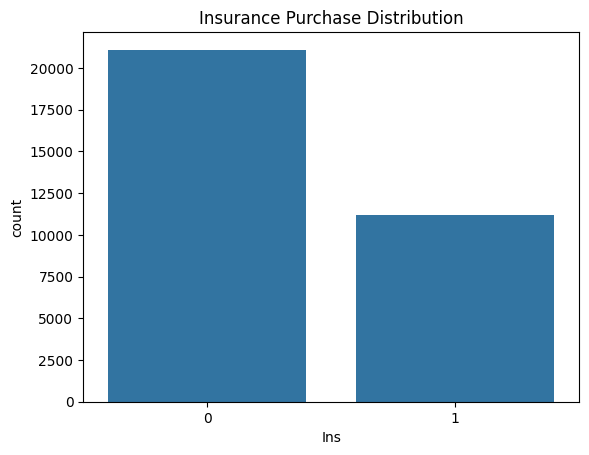

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Ins', data=df)
plt.title("Insurance Purchase Distribution")
plt.show()

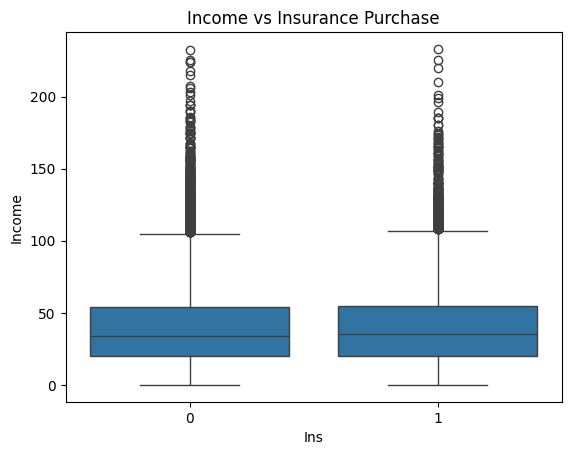

In [7]:
sns.boxplot(x='Ins', y='Income', data=df)
plt.title("Income vs Insurance Purchase")
plt.show()


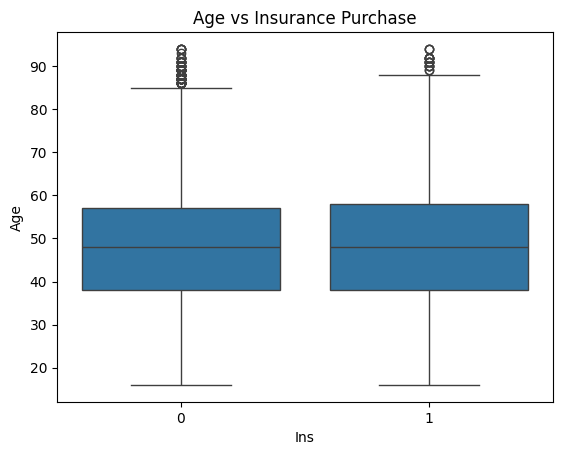

In [8]:
sns.boxplot(x='Ins', y='Age', data=df)
plt.title("Age vs Insurance Purchase")
plt.show()

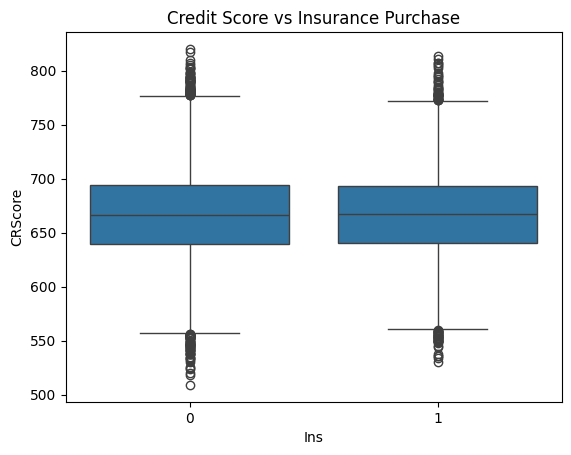

In [9]:
sns.boxplot(x='Ins', y='CRScore', data=df)
plt.title("Credit Score vs Insurance Purchase")
plt.show()

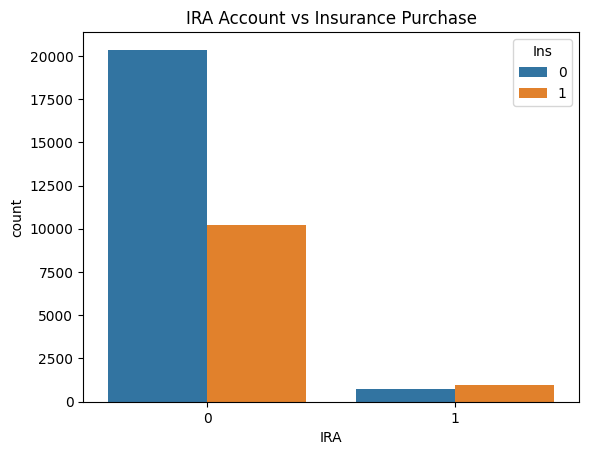

In [10]:
sns.countplot(x='IRA', hue='Ins', data=df)
plt.title("IRA Account vs Insurance Purchase")
plt.show()

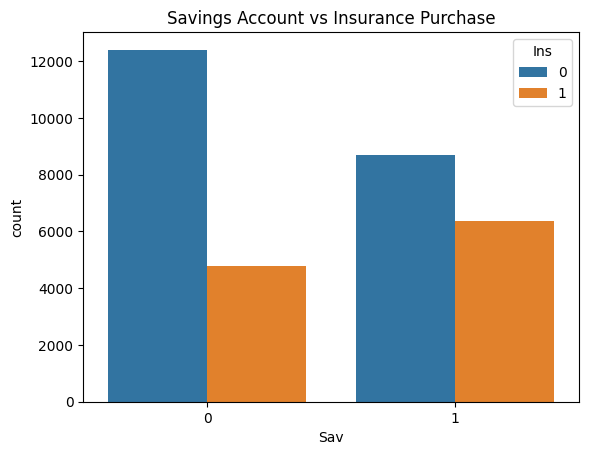

In [11]:
sns.countplot(x='Sav', hue='Ins', data=df)
plt.title("Savings Account vs Insurance Purchase")
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop('Ins', axis=1)
y = df['Ins']

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
!pip install scikit-learn

In [14]:
from sklearn.model_selection import train_test_split

# Define X and y
X = df.drop('Ins', axis=1)
y = df['Ins']

# Convert categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [15]:
# Fill missing numeric values with the median
X = df.drop('Ins', axis=1)
y = df['Ins']

# Convert categorical variables first
X = pd.get_dummies(X, drop_first=True)

# Fill missing values
X = X.fillna(X.median())

# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)
roc1 = roc_auc_score(y_test, model1.predict_proba(X_test)[:, 1])

roc1

c:\Users\jjfrowner01\OneDrive - Fayetteville State University\FTCC\UNCG\ISM 646\PythonProjects\SampleSuperstore\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.7562621633293873

In [17]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)
roc2 = roc_auc_score(y_test, model2.predict_proba(X_test)[:,1])

roc2

0.624533247816076

In [18]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)

pred3 = model3.predict(X_test)
roc3 = roc_auc_score(y_test, model3.predict_proba(X_test)[:,1])

roc3

0.7949261733319987

In [19]:
from sklearn.neural_network import MLPClassifier

model4 = MLPClassifier(max_iter=500, random_state=42)
model4.fit(X_train, y_train)

pred4 = model4.predict(X_test)
roc4 = roc_auc_score(y_test, model4.predict_proba(X_test)[:,1])

roc4

0.6705861454960197